# Data pipeline prototype (validation + visualization)

This notebook is **read-only with respect to `data/`**: it only validates and visualizes the existing dataset you provided.


Expected layout:
- `data/combined/combined_*.npz`
  - must contain key `data` with shape `(C, H, W)`
  - may contain `channels` (list of channel names)
  - may contain `timestamp` (string)


We will:
1. Load a few samples and inspect shapes/channels
2. Visualize channels
3. Run the existing validator (`src.data.validate_combined_dataset`) via subprocess using `py -3.12`


In [1]:
from __future__ import annotations

import glob
import os
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Robust repo root detection (works whether you run from repo root or from notebook/)
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src").exists():
    raise RuntimeError(f"Could not locate repo root containing 'src/' from cwd={Path.cwd()}")

DATA_DIR = REPO_ROOT / "data" / "combined"

print("Repo:", REPO_ROOT)
print("Data dir:", DATA_DIR)
assert DATA_DIR.exists(), f"Missing {DATA_DIR}"

Repo: C:\Users\PC\Desktop\ts\morocco-weather-nowcasting
Data dir: C:\Users\PC\Desktop\ts\morocco-weather-nowcasting\data\combined


In [3]:
files = sorted(glob.glob(str(DATA_DIR / "combined_*.npz")))
print("combined files:", len(files))
print("first 5:")
for f in files[:5]:
    print(" ", os.path.basename(f))

assert files, "No combined_*.npz files found"

# Load a few samples
N = min(3, len(files))
samples = [np.load(files[i], allow_pickle=True) for i in range(N)]

for i, z in enumerate(samples, start=1):
    data = z["data"]
    channels = [str(c) for c in z["channels"]] if "channels" in z else None
    ts = str(z["timestamp"]) if "timestamp" in z else None
    print(f"\nSample {i}: {os.path.basename(files[i-1])}")
    print("  data shape:", data.shape, "dtype:", data.dtype)
    if channels:
        print("  channels:", channels)
    if ts:
        print("  timestamp:", ts)

combined files: 67
first 5:
  combined_20200321_032743.npz
  combined_20200321_034243.npz
  combined_20200321_035742.npz
  combined_20200321_041242.npz
  combined_20200321_042742.npz

Sample 1: combined_20200321_032743.npz
  data shape: (4, 557, 521) dtype: float64
  channels: ['satellite', 'wind_u', 'wind_v', 'wind_speed']
  timestamp: 20200321_032743

Sample 2: combined_20200321_034243.npz
  data shape: (4, 557, 521) dtype: float64
  channels: ['satellite', 'wind_u', 'wind_v', 'wind_speed']
  timestamp: 20200321_034243

Sample 3: combined_20200321_035742.npz
  data shape: (4, 557, 521) dtype: float64
  channels: ['satellite', 'wind_u', 'wind_v', 'wind_speed']
  timestamp: 20200321_035742


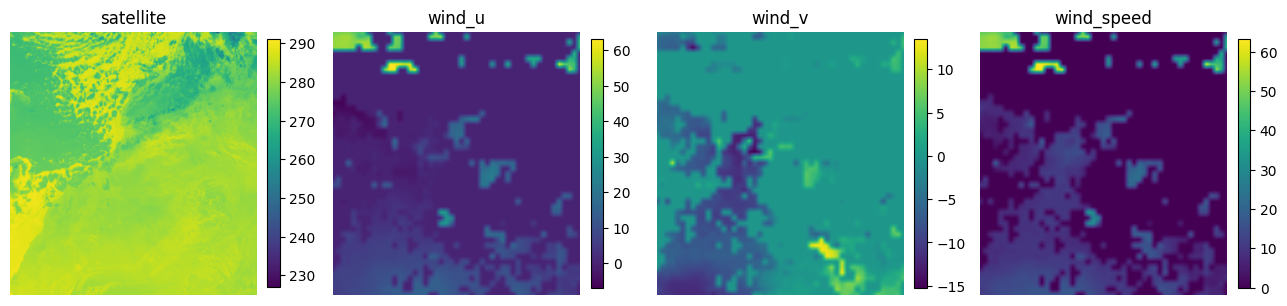

In [4]:
# Visualize each channel for the first sample
z0 = samples[0]
x0 = z0["data"].astype(np.float32)  # (C,H,W)
ch0 = [str(c) for c in z0["channels"]] if "channels" in z0 else [f"ch{i}" for i in range(x0.shape[0])]

C = x0.shape[0]
fig, axes = plt.subplots(1, C, figsize=(4*C, 4))
if C == 1:
    axes = [axes]
for ci in range(C):
    ax = axes[ci]
    im = ax.imshow(x0[ci], cmap="viridis")
    ax.set_title(ch0[ci])
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

In [2]:
# Run validator via subprocess (Windows-friendly, prefers py -3.12)
cmd = [
    "py", "-3.12", "-m", "src.data.validate_combined_dataset",
    "--data-dir", "data/combined",
    "--expected-step-min", "15",
    "--step-tolerance-seconds", "90",
    "--config", "configs/vit_config_l2.yaml",
    "--channel-stats",
]

print("$", " ".join(cmd))
p = subprocess.run(cmd, cwd=str(REPO_ROOT), text=True, capture_output=True)
print("returncode:", p.returncode)
print(p.stdout)
if p.stderr.strip():
    print("[stderr]")
    print(p.stderr)
assert p.returncode == 0, "Validator failed"

$ py -3.12 -m src.data.validate_combined_dataset --data-dir data/combined --expected-step-min 15 --step-tolerance-seconds 90 --config configs/vit_config_l2.yaml --channel-stats
returncode: 0
[validate_combined_dataset] OK
  files: 67
  time:  2020-03-21 03:27:43 -> 2020-03-25 06:12:43 (expected_step_min=15.0 tol_s=90.0)
  deltas_min: min=14.9833 max=4950.02 unique_steps=4 bad_steps=1 gaps=1 longest_run=64
  shape: (4, 557, 521) (C,H,W)
  channels: ['satellite', 'wind_u', 'wind_v', 'wind_speed']
[validate_combined_dataset] Channel stats (files=67/67):
  00          satellite  min=221.569 max=326.853 mean=288.085 std=12.987 zero%=0.00%
  01             wind_u  min=-9.55494 max=69.3478 mean=3.28157 std=6.39108 zero%=49.61%
  02             wind_v  min=-24.3692 max=16.8817 mean=-1.66839 std=3.44117 zero%=49.61%
  03         wind_speed  min=0 max=69.4907 mean=4.54333 std=6.80963 zero%=49.61%
[validate_combined_dataset] WARNING: config image_size does not match dataset H,W; this is OK only i